## DECISION TREE CLASSIFIER


In [18]:
# importing the libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [19]:
# importing the dataset
# Iris dataset is available in sklearn library
from sklearn.datasets import load_iris
iris = load_iris()


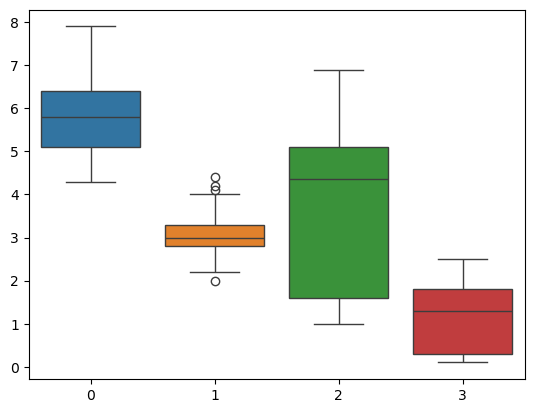

In [20]:
# checking the outlier in the dataset
import seaborn as sns
sns.boxplot(data=iris.data)
plt.show()


Lower bound: [ 3.15  2.05 -3.65 -1.95]
Upper bound: [ 8.35  4.05 10.35  4.05]
Original shape: (150, 4)
Shape after outlier removal: (146, 4)


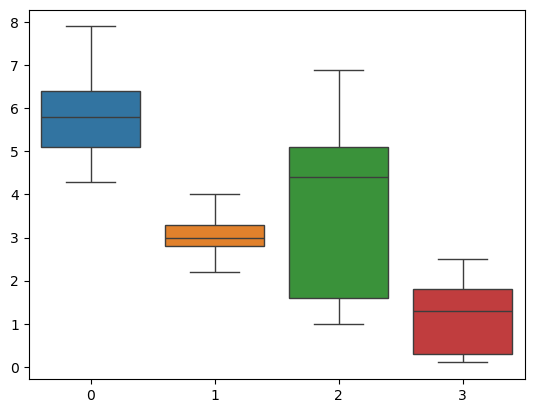

In [23]:
# handling the outlier using iqr method
Q1 = np.percentile(iris.data, 25, axis=0)
Q3 = np.percentile(iris.data, 75, axis=0)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)

# remove rows that are within the bounds for all features
mask = np.all((iris.data >= lower_bound) & (iris.data <= upper_bound), axis=1)
outlier_removed_data = iris.data[mask]
print("Original shape:", iris.data.shape)
print("Shape after outlier removal:", outlier_removed_data.shape)

# checking the outlier in the dataset after removing the outlier
sns.boxplot(data=outlier_removed_data)
plt.show()






In [24]:
# feature scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaled_data = scaler.fit_transform(outlier_removed_data)
print("Original data:\n", outlier_removed_data[:5])
print("Scaled data:\n", scaled_data[:5])


Original data:
 [[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]
Scaled data:
 [[-0.9105154   1.15915054 -1.37376391 -1.34852508]
 [-1.15112218 -0.10192233 -1.37376391 -1.34852508]
 [-1.39172896  0.40250682 -1.43084118 -1.34852508]
 [-1.51203236  0.15029225 -1.31668664 -1.34852508]
 [-1.03081879  1.41136512 -1.37376391 -1.34852508]]


In [25]:
# target variable
print(iris["target"])

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]


In [26]:
# test train split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(scaled_data, iris.target[mask], test_size=0.2, random_state=42)
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)


X_train shape: (116, 4)
X_test shape: (30, 4)
y_train shape: (116,)
y_test shape: (30,)


In [27]:
# training the decision tree model
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)


,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [29]:
# predicting the test set results
y_pred = model.predict(X_test)
# printing the predicted and actual values
print("Predicted values:", y_pred)
print("Actual values:", y_test)



Predicted values: [0 2 0 0 0 2 0 1 2 0 0 1 2 1 2 0 1 2 0 1 2 2 0 1 0 1 1 2 2 0]
Actual values: [0 2 0 0 0 2 0 1 1 0 0 2 2 1 2 0 1 2 0 1 2 2 0 1 0 1 1 2 2 0]


In [30]:
# evaluating the model
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


Accuracy: 0.9333333333333333
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       0.88      0.88      0.88         8
           2       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.92      0.92      0.92        30
weighted avg       0.93      0.93      0.93        30

Confusion Matrix:
 [[12  0  0]
 [ 0  7  1]
 [ 0  1  9]]


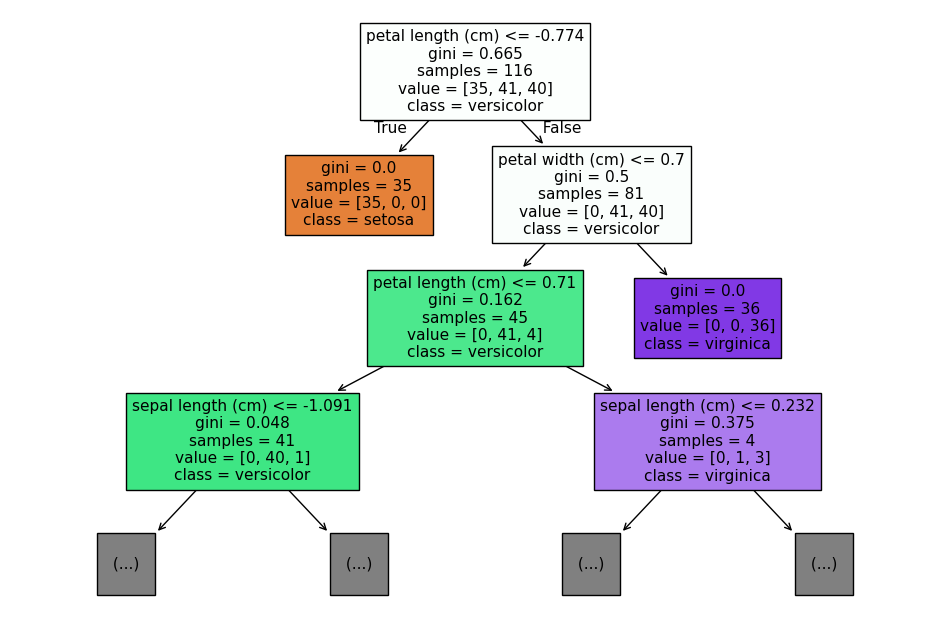

In [33]:
# visualizing the decision tree
from sklearn.tree import plot_tree
plt.figure(figsize=(12, 8))
plot_tree(model, filled=True, feature_names=iris.feature_names, class_names=iris.target_names,max_depth=3)
plt.show()

In [35]:
# hyperparameter tuning 
params={
    'criterion': ['gini', 'entropy'],
    'max_depth': [1,2,3,4,5,6],
    'splitter': ['best', 'random'],
    'max_features': ['auto', 'sqrt', 'log2']
}



In [36]:
params

{'criterion': ['gini', 'entropy'],
 'max_depth': [1, 2, 3, 4, 5, 6],
 'splitter': ['best', 'random'],
 'max_features': ['auto', 'sqrt', 'log2']}

In [38]:
# import warning
import warnings
warnings.filterwarnings("ignore")

In [40]:
from sklearn.model_selection import GridSearchCV
grid_search = GridSearchCV(estimator=model, param_grid=params, cv=5)
grid_search.fit(X_train, y_train)


,estimator,DecisionTreeC...ndom_state=42)
,param_grid,"{'criterion': ['gini', 'entropy'], 'max_depth': [1, 2, ...], 'max_features': ['auto', 'sqrt', ...], 'splitter': ['best', 'random']}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'gini'


In [41]:
grid_search.best_params_

{'criterion': 'gini',
 'max_depth': 5,
 'max_features': 'sqrt',
 'splitter': 'best'}

In [42]:
grid_search.best_score_

np.float64(0.9652173913043478)

In [43]:
y_pred = grid_search.predict(X_test)

In [44]:
y_pred 

array([0, 2, 0, 0, 0, 2, 0, 1, 2, 0, 0, 1, 2, 1, 2, 0, 1, 2, 0, 1, 2, 2,
       0, 1, 0, 1, 1, 2, 2, 0])

In [46]:
# confusion matrix and classification report after hyperparameter tuning
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       0.88      0.88      0.88         8
           2       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.92      0.92      0.92        30
weighted avg       0.93      0.93      0.93        30

Confusion Matrix:
 [[12  0  0]
 [ 0  7  1]
 [ 0  1  9]]


In [47]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9333333333333333
